<a href="https://colab.research.google.com/github/AngeNana23/Assignment-11/blob/main/Assignment11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://github.com/AngeNana23/Assignment-11/blob/main/Assignment11.ipynb


https://colab.research.google.com/drive/1WB9V3zQxIPDHxA4gRIwHwAKzGYtirRxr?usp=sharing



In [23]:
# Mount Google Drive so Colab can access your dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# OS → navigate folders
import os

# OpenCV → image loading & resizing
import cv2

# NumPy → numerical operations & arrays
import numpy as np

# Matplotlib & Seaborn → visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn → ML tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC

In [25]:
# Define a fixed image size so all images are uniform
IMG_SIZE = 32

# Lists to store image data and labels
data = []
labels = []

# Store class (folder) names
class_names = []

# Path to dataset in Google Drive
dataset_path = "/content/drive/MyDrive/images"

# Get folder names (each folder = one class)
# Sorting ensures consistent label assignment
categories = sorted(os.listdir(dataset_path))

# Loop through each category (folder)
for label, category in enumerate(categories):

    # Save class name (for later interpretation)
    class_names.append(category)

    # Path to specific category folder
    folder_path = os.path.join(dataset_path, category)

    # Loop through each image in the folder
    for img_name in os.listdir(folder_path):

        # Full image path
        img_path = os.path.join(folder_path, img_name)

        try:
            # Read image using OpenCV
            img = cv2.imread(img_path)

            # Resize image to uniform size (32x32)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # Flatten image into 1D array (required for Random Forest)
            img = img.flatten()

            # Append processed image to dataset
            data.append(img)

            # Append corresponding label
            labels.append(label)

        # Skip unreadable/corrupt images
        except:
            continue

# Convert lists to NumPy arrays
X = np.array(data)
y = np.array(labels)

# Normalize pixel values (0–255 → 0–1)
X = X / 255.0

# Display dataset info
print("Classes:", class_names)
print("Dataset shape:", X.shape)

Classes: ['dalmatian', 'dollar_bill', 'pizza', 'soccer_ball', 'sunflower']
Dataset shape: (309, 3072)


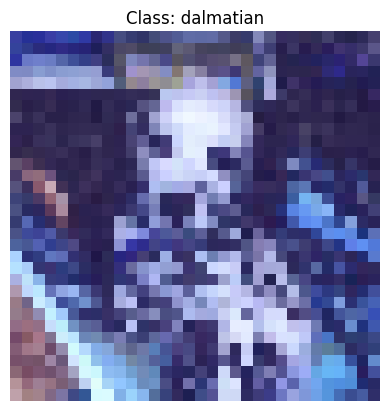

In [26]:
# Display one sample image to verify preprocessing
plt.imshow(X[0].reshape(32,32,3))
plt.title(f"Class: {class_names[y[0]]}")
plt.axis('off')
plt.show()

In [27]:
# Split dataset:
# 80% training, 20% testing
# stratify=y ensures balanced class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
# Define hyperparameter grid for tuning
param_grid = {
    'n_estimators': [50, 100],          # number of trees
    'max_depth': [10, 20, None],        # depth of each tree
    'min_samples_split': [2, 5],        # min samples to split node
    'min_samples_leaf': [1, 2]          # min samples at leaf
}

# Initialize Random Forest model
rf = RandomForestClassifier(random_state=42)

# GridSearchCV → finds best parameter combination
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,              # 3-fold cross-validation
    n_jobs=-1,         # use all CPU cores
    verbose=1
)

# Train model using training data
grid.fit(X_train, y_train)

# Display best parameters found
print("Best Parameters:", grid.best_params_)

# Retrieve best trained model
best_model = grid.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [29]:
# Make predictions on test data
y_pred = best_model.predict(X_test)

# Print accuracy score
print("Accuracy:", accuracy_score(y_test, y_pred))

# Print detailed classification metrics
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=class_names))

Accuracy: 0.7258064516129032

Classification Report:
               precision    recall  f1-score   support

   dalmatian       0.75      0.64      0.69        14
 dollar_bill       1.00      0.70      0.82        10
       pizza       0.55      0.60      0.57        10
 soccer_ball       0.64      0.82      0.72        11
   sunflower       0.78      0.82      0.80        17

    accuracy                           0.73        62
   macro avg       0.74      0.72      0.72        62
weighted avg       0.75      0.73      0.73        62



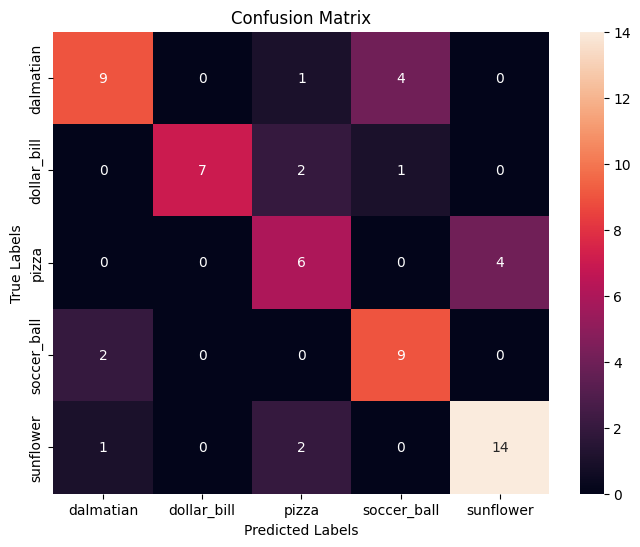

In [30]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

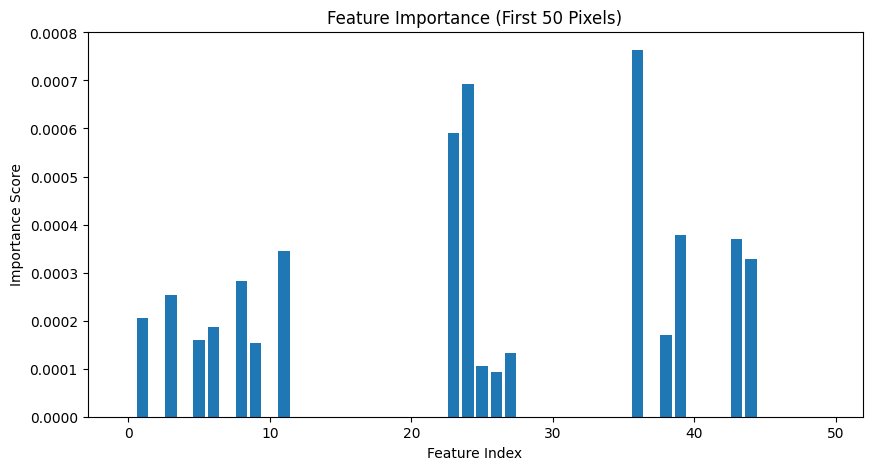

In [31]:
# Extract feature importance scores
importances = best_model.feature_importances_

# Plot first 50 feature importances
plt.figure(figsize=(10,5))
plt.bar(range(50), importances[:50])

plt.title("Feature Importance (First 50 Pixels)")
plt.xlabel("Feature Index")
plt.ylabel("Importance Score")
plt.show()

In [32]:
# Function to predict class of a new image
def predict_image(image_path):

    # Load image
    img = cv2.imread(image_path)

    # Resize to match training size
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Flatten image
    img = img.flatten()

    # Normalize
    img = img / 255.0

    # Reshape for model input
    img = img.reshape(1, -1)

    # Predict class
    pred = best_model.predict(img)[0]

    # Return class name instead of number
    return class_names[pred]

In [34]:
# Test the prediction function with a sample image
test_path = "/content/drive/MyDrive/images/soccer_ball/image_0064.jpg"

print("Predicted Class:", predict_image(test_path))

Predicted Class: soccer_ball


In [36]:
# Initialize SVM model
svm = SVC(kernel='rbf')

# Train SVM model
svm.fit(X_train, y_train)

# Make predictions
svm_pred = svm.predict(X_test)

# Evaluate SVM performance
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.7903225806451613
